# Karar Ağacı Uygulaması (Diabetes Veri Seti)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:

# Veri setini yükle
df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:

# Bağımsız ve bağımlı değişkenler
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [ ]:

# Train-Test bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:

# Model oluşturma
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:

# Tahmin
y_pred = model.predict(X_test)

# Değerlendirme
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7987012987012987

Confusion Matrix:
 [[88 12]
 [19 35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       100
           1       0.74      0.65      0.69        54

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.80      0.80      0.80       154



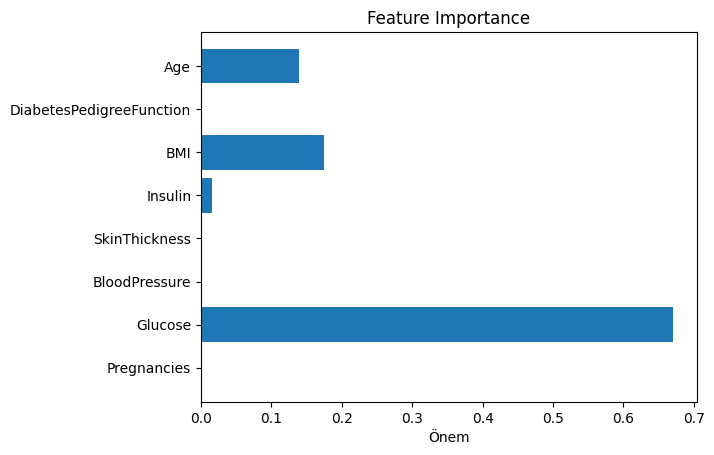

In [ ]:
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Önem")
plt.title("Feature Importance")
plt.show()


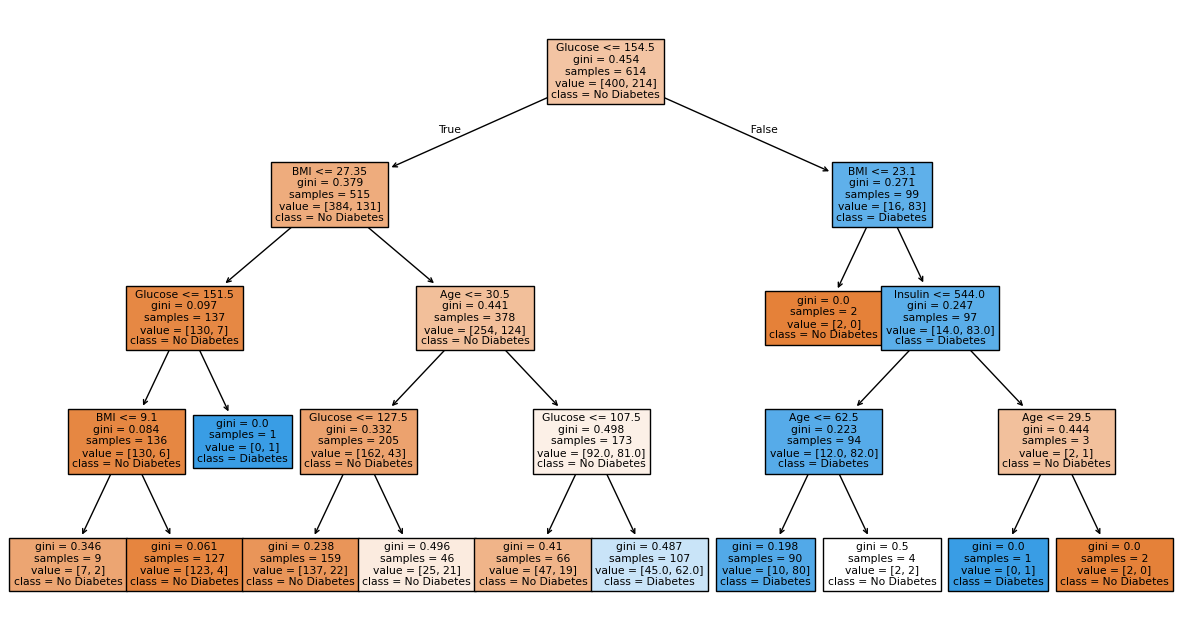

In [ ]:
# Karar ağacını görselleştirme
plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=['No Diabetes','Diabetes'], filled=True)
plt.show()


# Decision Tree - Gelişmiş Analiz (GridSearchCV, max_depth, Pruning)

In [ ]:
from sklearn.model_selection import GridSearchCV

## 1. GridSearchCV ile Hyperparameter Tuning

In [ ]:
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("En iyi parametreler:", grid.best_params_)

best_model = grid.best_estimator_
y_grid_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_grid_pred))

En iyi parametreler: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Test Accuracy: 0.6948051948051948


## 2. Farklı max_depth Karşılaştırması

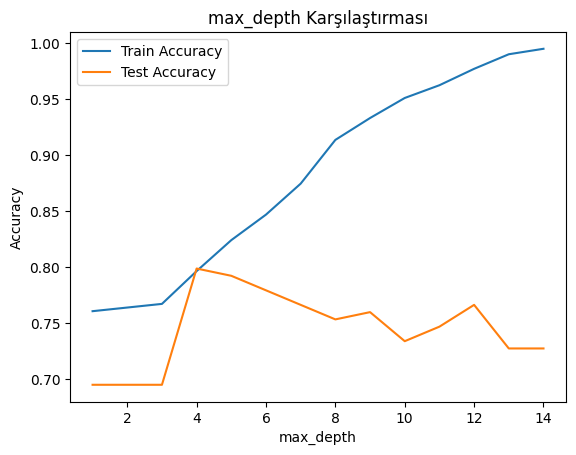

In [ ]:
depths = range(1, 15)
train_acc = []
test_acc = []

for d in depths:
    max_model = DecisionTreeClassifier(max_depth=d, random_state=42)
    max_model.fit(X_train, y_train)

    train_acc.append(max_model.score(X_train, y_train))
    test_acc.append(max_model.score(X_test, y_test))

plt.figure()
plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("max_depth Karşılaştırması")
plt.legend()
plt.show()


## 3. Pruning (Cost Complexity Pruning) Analizi

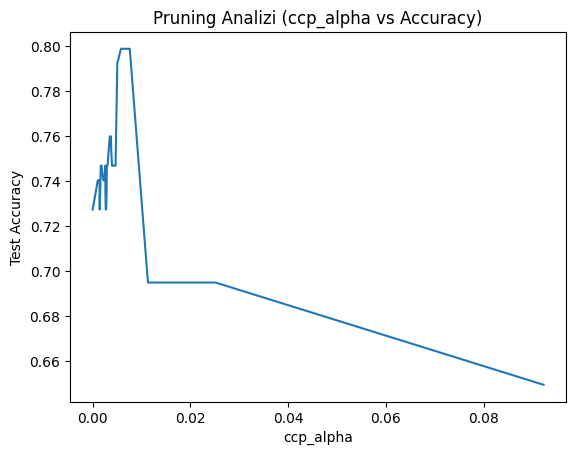

In [ ]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

models = []
test_scores = []

for alpha in ccp_alphas:
    pruning_model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    pruning_model.fit(X_train, y_train)
    models.append(pruning_model)
    test_scores.append(pruning_model.score(X_test, y_test))

plt.figure()
plt.plot(ccp_alphas, test_scores)
plt.xlabel("ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Pruning Analizi (ccp_alpha vs Accuracy)")
plt.show()
